In [4]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content

!cp /content/drive/MyDrive/MPNet-master.zip .
!unzip -oq MPNet-master.zip

!cp /content/drive/MyDrive/dataset.zip .
!unzip -oq dataset.zip

%cd /content/MPNet-master/MPNet

!sed -i 's/print \"epoch\" + str(epoch)/print(\"epoch\" + str(epoch))/g' AE/CAE.py
!sed -i 's/print \"--average loss:\"/print(\"--average loss:\")/g' AE/CAE.py

import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from AE.CAE import Encoder
from Model.model import MLP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

encoder = Encoder().to(device)
encoder.load_state_dict(
    torch.load("/content/drive/MyDrive/cae_encoder.pkl", map_location=device)
)
encoder.eval()
print("Encoder loaded")

pnet = MLP(32 + 2, 2).to(device)
pnet.load_state_dict(
    torch.load("/content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd_final.pkl", map_location=device)
)
pnet.eval()
print("MPNet loaded")


def is_in_collision(point, obs_xy, threshold=0.03):
    dists = np.linalg.norm(obs_xy - point, axis=1)
    return np.any(dists < threshold)


def generate_baseline_path(start, goal, obs_code, max_steps=100):
    current = torch.tensor(start, dtype=torch.float32).to(device)
    goal_t = torch.tensor(goal, dtype=torch.float32).to(device)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():
        for _ in range(max_steps):
            inp = torch.cat([obs_code, current]).unsqueeze(0)
            next_state = pnet(inp).squeeze(0)

            current = next_state
            path.append(current.detach().cpu().numpy())

            dist = torch.norm(current - goal_t).item()
            if dist < 0.1:
                break

    return np.array(path), dist


failure_cases = []

for env_id in range(1, 15):
    print("Processing env:", env_id)

    obs = np.fromfile(f"../dataset/obs_cloud/obc{env_id}.dat")
    obs_xy = obs.reshape(-1, 2)

    obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

    with torch.no_grad():
        obs_code = encoder(obs_input).squeeze(0)

    for case_id in range(300):
        try:
            expert = np.fromfile(
                f"../dataset/e{env_id}/path{case_id}.dat"
            ).reshape(-1, 2)

            start = expert[0]
            goal = expert[-1]

            path, final_dist = generate_baseline_path(start, goal, obs_code)

            collision = any(is_in_collision(p, obs_xy) for p in path)

            expert_length = np.sum(
                np.linalg.norm(expert[1:] - expert[:-1], axis=1)
            )

            path_length = np.sum(
                np.linalg.norm(path[1:] - path[:-1], axis=1)
            )

            ratio = path_length / expert_length

            failure_type = []
            if collision:
                failure_type.append("collision")
            if final_dist > 0.1:
                failure_type.append("goal_failure")
            if ratio > 1.3:
                failure_type.append("unstable_path")

            if failure_type:
                failure_cases.append({
                    "env": env_id,
                    "case": case_id,
                    "failure_type": failure_type,
                    "collision": collision,
                    "final_dist": final_dist,
                    "ratio": ratio,
                    "path": path,
                    "expert": expert,
                    "obs_xy": obs_xy,
                    "start": start,
                    "goal": goal
                })

        except Exception:
            continue

print("failure cases:", len(failure_cases))

collision_cases = [c for c in failure_cases if c["collision"]]
goal_failure_cases = [c for c in failure_cases if c["final_dist"] > 0.1]
unstable_cases = [c for c in failure_cases if c["ratio"] > 1.3]

print("Collision cases:", len(collision_cases))
print("Goal failure cases:", len(goal_failure_cases))
print("Unstable path cases:", len(unstable_cases))

print("First 10 failure summaries:")
for c in failure_cases[:10]:
    print(
        "env:", c["env"],
        "case:", c["case"],
        "type:", c["failure_type"],
        "final_dist:", round(c["final_dist"], 4),
        "ratio:", round(c["ratio"], 4),
        "collision:", c["collision"]
    )


Mounted at /content/drive
/content
/content/MPNet-master/MPNet


SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)? (CAE.py, line 82)

In [6]:
!sed -i 's/print avg_loss\/(len(obs)\/args.batch_size)/print(avg_loss\/(len(obs)\/args.batch_size))/g' AE/CAE.py


In [8]:
!sed -i 's/print \"epoch\" + str(epoch)/print(\"epoch\" + str(epoch))/g' AE/CAE.py
!sed -i 's/print \"--average loss:\"/print(\"--average loss:\")/g' AE/CAE.py
!sed -i 's/print avg_loss\/(len(obs)\/args.batch_size)/print(avg_loss\/(len(obs)\/args.batch_size))/g' AE/CAE.py


In [10]:
!sed -i 's/print "--Validation average loss:"/print("--Validation average loss:")/g' AE/CAE.py


In [12]:
!grep -n "print " AE/CAE.py


97:	print avg_loss/(5000/args.batch_size)


In [13]:
!sed -i 's/print avg_loss\/(5000\/args.batch_size)/print(avg_loss\/(5000\/args.batch_size))/g' AE/CAE.py


In [14]:
!grep -n "print " AE/CAE.py


In [16]:
!pwd
!find . -maxdepth 3 -type f | grep -i "model.py"
!find . -maxdepth 3 -type d | grep -i "model"



/content/MPNet-master/MPNet
./model.py


In [17]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from AE.CAE import Encoder
from model import MLP


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [19]:
encoder = Encoder().to(device)

encoder.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/cae_encoder.pkl",
        map_location=device
    )
)

encoder.eval()

print("Encoder loaded")

Encoder loaded


In [22]:
!ls -lh /content/drive/MyDrive/*.pkl


-rw------- 1 root root 6.2M Apr 29 16:48 /content/drive/MyDrive/cae_decoder.pkl
-rw------- 1 root root 6.2M Apr 29 16:48 /content/drive/MyDrive/cae_encoder.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd100.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd150.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd200.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd250.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd300.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd350.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd400.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd450.pkl
-rw------- 1 root root  15M Apr 29 16:47 /content/drive/MyDrive/mlp_100_

In [23]:
pnet = MLP(32, 2).to(device)

pnet.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd_final.pkl",
        map_location=device
    )
)

pnet.eval()

print("MPNet loaded")


MPNet loaded


In [25]:
!find /content -path "*obs_cloud*" -type d
!find /content -name "obc1.dat"


/content/dataset/obs_cloud
/content/dataset/obs_cloud/obc1.dat


In [26]:
DATASET_DIR = "/content/dataset"

obs = np.fromfile(f"{DATASET_DIR}/obs_cloud/obc1.dat")
obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

print(obs_code.shape)


torch.Size([28])


In [27]:
def is_in_collision(point, obs_xy, threshold=0.03):
    dists = np.linalg.norm(obs_xy - point, axis=1)
    return np.any(dists < threshold)

In [28]:
def generate_baseline_path(start, goal, obs_code, max_steps=100):

    current = torch.tensor(start, dtype=torch.float32).to(device)
    goal_t = torch.tensor(goal, dtype=torch.float32).to(device)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():

        for _ in range(max_steps):

            inp = torch.cat([current, goal_t, obs_code]).unsqueeze(0)

            next_state = pnet(inp).squeeze(0)

            current = next_state

            path.append(current.detach().cpu().numpy())

            dist = torch.norm(current - goal_t).item()

            if dist < 0.1:
                break

    return np.array(path), dist


In [29]:
failure_cases = []

for env_id in range(1, 15):

    print("Processing env:", env_id)

    obs = np.fromfile(f"{DATASET_DIR}/obs_cloud/obc{env_id}.dat")
    obs_xy = obs.reshape(-1, 2)

    obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

    with torch.no_grad():
        obs_code = encoder(obs_input).squeeze(0)

    for case_id in range(300):

        try:

            expert = np.fromfile(
                f"{DATASET_DIR}/e{env_id}/path{case_id}.dat"
            ).reshape(-1, 2)

            start = expert[0]
            goal = expert[-1]

            path, final_dist = generate_baseline_path(
                start, goal, obs_code
            )

            collision = False

            for p in path:
                if is_in_collision(p, obs_xy):
                    collision = True
                    break

            expert_length = np.sum(
                np.linalg.norm(expert[1:] - expert[:-1], axis=1)
            )

            path_length = np.sum(
                np.linalg.norm(path[1:] - path[:-1], axis=1)
            )

            ratio = path_length / expert_length

            failure_type = []

            if collision:
                failure_type.append("collision")

            if final_dist > 0.1:
                failure_type.append("goal_failure")

            if ratio > 1.3:
                failure_type.append("unstable_path")

            if failure_type:

                failure_cases.append({
                    "env": env_id,
                    "case": case_id,
                    "failure_type": failure_type,
                    "collision": collision,
                    "final_dist": final_dist,
                    "ratio": ratio,
                    "path": path,
                    "expert": expert,
                    "obs_xy": obs_xy,
                    "start": start,
                    "goal": goal
                })

        except Exception as e:
            continue

print("failure cases:", len(failure_cases))


Processing env: 1
Processing env: 2
Processing env: 3
Processing env: 4
Processing env: 5
Processing env: 6
Processing env: 7
Processing env: 8
Processing env: 9
Processing env: 10
Processing env: 11
Processing env: 12
Processing env: 13
Processing env: 14
failure cases: 4200


In [30]:
collision_cases = [c for c in failure_cases if c["collision"]]
goal_failure_cases = [c for c in failure_cases if c["final_dist"] > 0.1]
unstable_cases = [c for c in failure_cases if c["ratio"] > 1.3]

print("Collision cases:", len(collision_cases))
print("Goal failure cases:", len(goal_failure_cases))
print("Unstable path cases:", len(unstable_cases))

print("First 10 failure summaries:")
for c in failure_cases[:10]:
    print(
        "env:", c["env"],
        "case:", c["case"],
        "type:", c["failure_type"],
        "final_dist:", round(c["final_dist"], 4),
        "ratio:", round(c["ratio"], 4),
        "collision:", c["collision"]
    )



Collision cases: 341
Goal failure cases: 4200
Unstable path cases: 4200
First 10 failure summaries:
env: 1 case: 0 type: ['goal_failure', 'unstable_path'] final_dist: 3.3039 ratio: 4.4904 collision: False
env: 1 case: 1 type: ['goal_failure', 'unstable_path'] final_dist: 3.4078 ratio: 10.7521 collision: False
env: 1 case: 2 type: ['goal_failure', 'unstable_path'] final_dist: 3.0466 ratio: 3.445 collision: False
env: 1 case: 3 type: ['goal_failure', 'unstable_path'] final_dist: 3.1487 ratio: 4.3103 collision: False
env: 1 case: 4 type: ['goal_failure', 'unstable_path'] final_dist: 3.7711 ratio: 6.5321 collision: False
env: 1 case: 5 type: ['goal_failure', 'unstable_path'] final_dist: 3.1828 ratio: 3.1426 collision: False
env: 1 case: 6 type: ['goal_failure', 'unstable_path'] final_dist: 3.2173 ratio: 6.6739 collision: False
env: 1 case: 7 type: ['goal_failure', 'unstable_path'] final_dist: 3.3517 ratio: 6.358 collision: False
env: 1 case: 8 type: ['goal_failure', 'unstable_path'] final_

In [31]:
test = failure_cases[0]

print("env:", test["env"], "case:", test["case"])
print("start:", test["start"])
print("goal:", test["goal"])
print("expert min/max:", test["expert"].min(), test["expert"].max())
print("path min/max:", test["path"].min(), test["path"].max())
print("final_dist:", test["final_dist"])
print("ratio:", test["ratio"])
print("path first 5:")
print(test["path"][:5])
print("path last 5:")
print(test["path"][-5:])


env: 1 case: 0
start: [0.54168682 0.64640174]
goal: [0.54536285 0.05120635]
expert min/max: 0.05120634919032907 0.6464017366657997
path min/max: -2.2636478 0.64640176
final_dist: 3.3039207458496094
ratio: 4.4903855150569765
path first 5:
[[ 0.54168683  0.64640176]
 [-2.2636478  -1.7686712 ]
 [-2.2624578  -1.6940138 ]
 [-2.2612257  -1.6920677 ]
 [-2.261215   -1.6920692 ]]
path last 5:
[[-2.2612152 -1.6920695]
 [-2.2612154 -1.6920696]
 [-2.2612152 -1.6920696]
 [-2.2612152 -1.6920695]
 [-2.2612154 -1.6920696]]


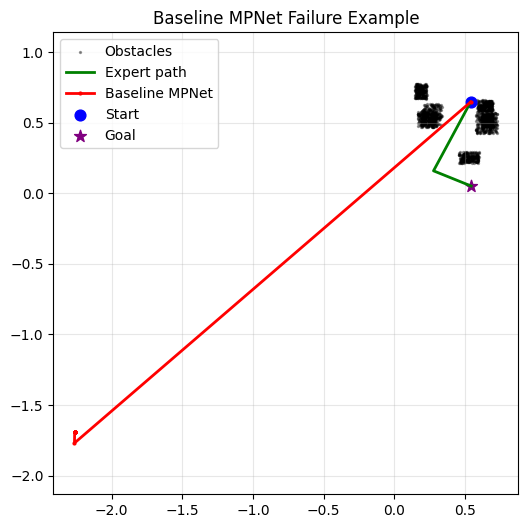

In [32]:
def plot_failure_case(case, title="Failure case"):
    plt.figure(figsize=(6, 6))

    obs_xy = case["obs_xy"]
    expert = case["expert"]
    path = case["path"]
    start = case["start"]
    goal = case["goal"]

    plt.scatter(obs_xy[:, 0], obs_xy[:, 1], s=2, c="black", alpha=0.35, label="Obstacles")
    plt.plot(expert[:, 0], expert[:, 1], c="green", linewidth=2, label="Expert path")
    plt.plot(path[:, 0], path[:, 1], c="red", linewidth=2, marker="o", markersize=2, label="Baseline MPNet")

    plt.scatter(start[0], start[1], c="blue", s=60, label="Start")
    plt.scatter(goal[0], goal[1], c="purple", s=80, marker="*", label="Goal")

    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_failure_case(failure_cases[0], "Baseline MPNet Failure Example")


In [33]:
test = failure_cases[0]

start = test["start"]
goal = test["goal"]
obs_xy = test["obs_xy"]

obs = np.fromfile(f"{DATASET_DIR}/obs_cloud/obc{test['env']}.dat")
obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

current = torch.tensor(start, dtype=torch.float32).to(device)
goal_t = torch.tensor(goal, dtype=torch.float32).to(device)

orders = {
    "current_goal_obs": torch.cat([current, goal_t, obs_code]),
    "goal_current_obs": torch.cat([goal_t, current, obs_code]),
    "obs_current_goal": torch.cat([obs_code, current, goal_t]),
    "obs_goal_current": torch.cat([obs_code, goal_t, current]),
    "current_obs_goal": torch.cat([current, obs_code, goal_t]),
    "goal_obs_current": torch.cat([goal_t, obs_code, current]),
}

with torch.no_grad():
    for name, inp in orders.items():
        out = pnet(inp.unsqueeze(0)).squeeze(0).detach().cpu().numpy()
        dist_to_goal = np.linalg.norm(out - goal)
        print(name, "->", out, "dist_to_goal:", dist_to_goal)


current_goal_obs -> [-2.2636478 -1.7686712] dist_to_goal: 3.347012838984504
goal_current_obs -> [-2.2470565 -1.7605106] dist_to_goal: 3.3286519678471977
obs_current_goal -> [0.4940415 0.5390538] dist_to_goal: 0.4905395131581514
obs_goal_current -> [0.53402466 0.10587756] dist_to_goal: 0.05583454445204468
current_obs_goal -> [-0.7983862 -0.2294925] dist_to_goal: 1.372753948355212
goal_obs_current -> [-0.8039532  -0.20667918] dist_to_goal: 1.3737389402589808


In [34]:
def generate_baseline_path(start, goal, obs_code, max_steps=100):

    current = torch.tensor(start, dtype=torch.float32).to(device)
    goal_t = torch.tensor(goal, dtype=torch.float32).to(device)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():

        for _ in range(max_steps):

            inp = torch.cat([obs_code, goal_t, current]).unsqueeze(0)

            next_state = pnet(inp).squeeze(0)

            current = next_state

            path.append(current.detach().cpu().numpy())

            dist = torch.norm(current - goal_t).item()

            if dist < 0.1:
                break

    return np.array(path), dist


In [35]:
failure_cases = []

for env_id in range(1, 15):

    print("Processing env:", env_id)

    obs = np.fromfile(f"{DATASET_DIR}/obs_cloud/obc{env_id}.dat")
    obs_xy = obs.reshape(-1, 2)

    obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

    with torch.no_grad():
        obs_code = encoder(obs_input).squeeze(0)

    for case_id in range(300):

        try:

            expert = np.fromfile(
                f"{DATASET_DIR}/e{env_id}/path{case_id}.dat"
            ).reshape(-1, 2)

            start = expert[0]
            goal = expert[-1]

            path, final_dist = generate_baseline_path(
                start, goal, obs_code
            )

            collision = False

            for p in path:
                if is_in_collision(p, obs_xy):
                    collision = True
                    break

            expert_length = np.sum(
                np.linalg.norm(expert[1:] - expert[:-1], axis=1)
            )

            path_length = np.sum(
                np.linalg.norm(path[1:] - path[:-1], axis=1)
            )

            ratio = path_length / expert_length

            failure_type = []

            if collision:
                failure_type.append("collision")

            if final_dist > 0.1:
                failure_type.append("goal_failure")

            if ratio > 1.3:
                failure_type.append("unstable_path")

            if failure_type:

                failure_cases.append({
                    "env": env_id,
                    "case": case_id,
                    "failure_type": failure_type,
                    "collision": collision,
                    "final_dist": final_dist,
                    "ratio": ratio,
                    "path": path,
                    "expert": expert,
                    "obs_xy": obs_xy,
                    "start": start,
                    "goal": goal
                })

        except Exception as e:
            continue

print("failure cases:", len(failure_cases))


Processing env: 1
Processing env: 2
Processing env: 3
Processing env: 4
Processing env: 5
Processing env: 6
Processing env: 7
Processing env: 8
Processing env: 9
Processing env: 10
Processing env: 11
Processing env: 12
Processing env: 13
Processing env: 14
failure cases: 1175


In [36]:
collision_cases = [c for c in failure_cases if c["collision"]]
goal_failure_cases = [c for c in failure_cases if c["final_dist"] > 0.1]
unstable_cases = [c for c in failure_cases if c["ratio"] > 1.3]

print("Total cases:", 14 * 300)
print("Failure cases:", len(failure_cases))
print("Failure rate:", len(failure_cases) / (14 * 300))

print("Collision cases:", len(collision_cases))
print("Goal failure cases:", len(goal_failure_cases))
print("Unstable path cases:", len(unstable_cases))

print("First 10 failure summaries:")
for c in failure_cases[:10]:
    print(
        "env:", c["env"],
        "case:", c["case"],
        "type:", c["failure_type"],
        "final_dist:", round(c["final_dist"], 4),
        "ratio:", round(c["ratio"], 4),
        "collision:", c["collision"]
    )


Total cases: 4200
Failure cases: 1175
Failure rate: 0.27976190476190477
Collision cases: 905
Goal failure cases: 276
Unstable path cases: 51
First 10 failure summaries:
env: 1 case: 11 type: ['goal_failure'] final_dist: 0.1069 ratio: 0.9492 collision: False
env: 1 case: 16 type: ['collision'] final_dist: 0.0669 ratio: 0.6275 collision: True
env: 1 case: 22 type: ['collision'] final_dist: 0.0517 ratio: 0.6925 collision: True
env: 1 case: 29 type: ['goal_failure'] final_dist: 0.1422 ratio: 0.6069 collision: False
env: 1 case: 32 type: ['goal_failure'] final_dist: 0.1213 ratio: 0.8002 collision: False
env: 1 case: 34 type: ['goal_failure'] final_dist: 0.135 ratio: 0.8826 collision: False
env: 1 case: 37 type: ['collision'] final_dist: 0.0473 ratio: 0.5217 collision: True
env: 1 case: 40 type: ['collision'] final_dist: 0.0483 ratio: 0.6471 collision: True
env: 1 case: 47 type: ['collision'] final_dist: 0.0767 ratio: 0.6496 collision: True
env: 1 case: 51 type: ['collision'] final_dist: 0.0

In [37]:
collision_case = collision_cases[0]
goal_case = max(goal_failure_cases, key=lambda x: x["final_dist"])
unstable_case = max(unstable_cases, key=lambda x: x["ratio"])

print("Collision example:")
print(
    "env:", collision_case["env"],
    "case:", collision_case["case"],
    "final_dist:", round(collision_case["final_dist"], 4),
    "ratio:", round(collision_case["ratio"], 4),
    "type:", collision_case["failure_type"]
)

print("Goal failure example:")
print(
    "env:", goal_case["env"],
    "case:", goal_case["case"],
    "final_dist:", round(goal_case["final_dist"], 4),
    "ratio:", round(goal_case["ratio"], 4),
    "type:", goal_case["failure_type"]
)

print("Unstable trajectory example:")
print(
    "env:", unstable_case["env"],
    "case:", unstable_case["case"],
    "final_dist:", round(unstable_case["final_dist"], 4),
    "ratio:", round(unstable_case["ratio"], 4),
    "type:", unstable_case["failure_type"]
)


Collision example:
env: 1 case: 16 final_dist: 0.0669 ratio: 0.6275 type: ['collision']
Goal failure example:
env: 9 case: 78 final_dist: 0.1612 ratio: 0.7703 type: ['goal_failure']
Unstable trajectory example:
env: 13 case: 268 final_dist: 0.0576 ratio: 4.2221 type: ['unstable_path']


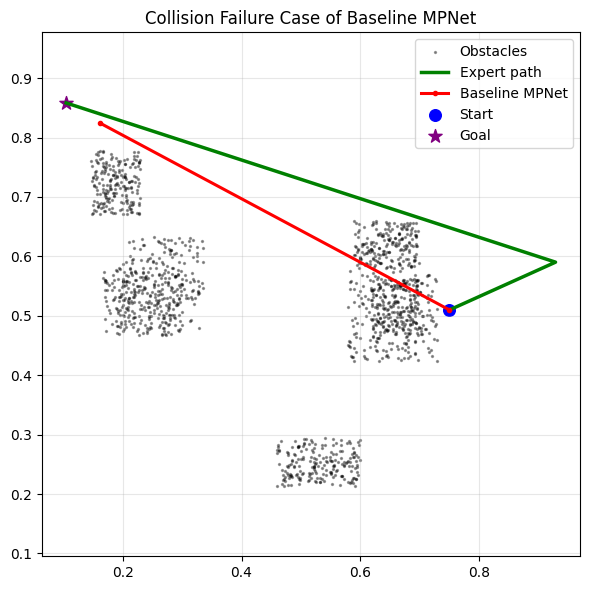

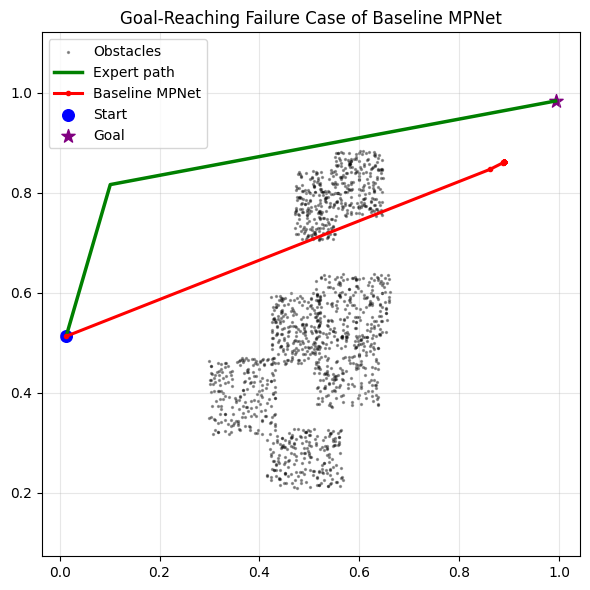

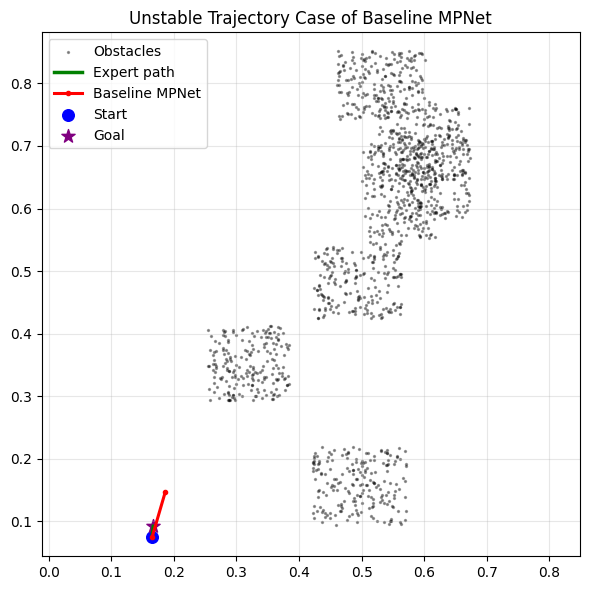

In [38]:
def plot_failure_case(case, title, save_path=None):
    plt.figure(figsize=(6, 6))

    obs_xy = case["obs_xy"]
    expert = case["expert"]
    path = case["path"]
    start = case["start"]
    goal = case["goal"]

    plt.scatter(
        obs_xy[:, 0],
        obs_xy[:, 1],
        s=2,
        c="black",
        alpha=0.35,
        label="Obstacles"
    )

    plt.plot(
        expert[:, 0],
        expert[:, 1],
        c="green",
        linewidth=2.5,
        label="Expert path"
    )

    plt.plot(
        path[:, 0],
        path[:, 1],
        c="red",
        linewidth=2.2,
        marker="o",
        markersize=3,
        label="Baseline MPNet"
    )

    plt.scatter(start[0], start[1], c="blue", s=70, label="Start")
    plt.scatter(goal[0], goal[1], c="purple", s=100, marker="*", label="Goal")

    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_failure_case(
    collision_case,
    "Collision Failure Case of Baseline MPNet",
    "/content/collision_failure_case.png"
)

plot_failure_case(
    goal_case,
    "Goal-Reaching Failure Case of Baseline MPNet",
    "/content/goal_failure_case.png"
)

plot_failure_case(
    unstable_case,
    "Unstable Trajectory Case of Baseline MPNet",
    "/content/unstable_trajectory_case.png"
)


In [39]:
def is_in_collision(point, obs_xy, threshold=0.03):
    dists = np.linalg.norm(obs_xy - point, axis=1)
    return np.any(dists < threshold)


def path_in_collision(path, obs_xy, threshold=0.03, samples_per_segment=20):
    for i in range(len(path) - 1):
        p0 = path[i]
        p1 = path[i + 1]

        for a in np.linspace(0, 1, samples_per_segment):
            p = (1 - a) * p0 + a * p1
            if is_in_collision(p, obs_xy, threshold):
                return True

    return False


In [40]:
failure_cases = []

for env_id in range(1, 15):

    print("Processing env:", env_id)

    obs = np.fromfile(f"{DATASET_DIR}/obs_cloud/obc{env_id}.dat")
    obs_xy = obs.reshape(-1, 2)

    obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)

    with torch.no_grad():
        obs_code = encoder(obs_input).squeeze(0)

    for case_id in range(300):

        try:

            expert = np.fromfile(
                f"{DATASET_DIR}/e{env_id}/path{case_id}.dat"
            ).reshape(-1, 2)

            start = expert[0]
            goal = expert[-1]

            path, final_dist = generate_baseline_path(
                start, goal, obs_code
            )

            collision = path_in_collision(path, obs_xy)

            expert_length = np.sum(
                np.linalg.norm(expert[1:] - expert[:-1], axis=1)
            )

            path_length = np.sum(
                np.linalg.norm(path[1:] - path[:-1], axis=1)
            )

            ratio = path_length / expert_length

            failure_type = []

            if collision:
                failure_type.append("collision")

            if final_dist > 0.1:
                failure_type.append("goal_failure")

            if ratio > 1.3:
                failure_type.append("unstable_path")

            if failure_type:

                failure_cases.append({
                    "env": env_id,
                    "case": case_id,
                    "failure_type": failure_type,
                    "collision": collision,
                    "final_dist": final_dist,
                    "ratio": ratio,
                    "path": path,
                    "expert": expert,
                    "obs_xy": obs_xy,
                    "start": start,
                    "goal": goal,
                    "expert_length": expert_length,
                    "path_length": path_length
                })

        except Exception as e:
            continue

print("failure cases:", len(failure_cases))


Processing env: 1
Processing env: 2
Processing env: 3
Processing env: 4
Processing env: 5
Processing env: 6
Processing env: 7
Processing env: 8
Processing env: 9
Processing env: 10
Processing env: 11
Processing env: 12
Processing env: 13
Processing env: 14
failure cases: 2560


In [41]:
collision_cases = [c for c in failure_cases if c["collision"]]
goal_failure_cases = [c for c in failure_cases if c["final_dist"] > 0.1]
unstable_cases = [c for c in failure_cases if c["ratio"] > 1.3]

print("Total cases:", 14 * 300)
print("Failure cases:", len(failure_cases))
print("Failure rate:", len(failure_cases) / (14 * 300))

print("Collision cases:", len(collision_cases))
print("Goal failure cases:", len(goal_failure_cases))
print("Unstable path cases:", len(unstable_cases))

print("First 10 failure summaries:")
for c in failure_cases[:10]:
    print(
        "env:", c["env"],
        "case:", c["case"],
        "type:", c["failure_type"],
        "final_dist:", round(c["final_dist"], 4),
        "ratio:", round(c["ratio"], 4),
        "collision:", c["collision"],
        "expert_length:", round(c["expert_length"], 4),
        "path_length:", round(c["path_length"], 4)
    )


Total cases: 4200
Failure cases: 2560
Failure rate: 0.6095238095238096
Collision cases: 2405
Goal failure cases: 276
Unstable path cases: 51
First 10 failure summaries:
env: 1 case: 0 type: ['collision'] final_dist: 0.0558 ratio: 0.6424 collision: True expert_length: 0.8415 path_length: 0.5406
env: 1 case: 2 type: ['collision'] final_dist: 0.074 ratio: 0.6625 collision: True expert_length: 1.1529 path_length: 0.7638
env: 1 case: 3 type: ['collision'] final_dist: 0.0232 ratio: 0.5794 collision: True expert_length: 0.8754 path_length: 0.5072
env: 1 case: 5 type: ['collision'] final_dist: 0.0924 ratio: 0.827 collision: True expert_length: 1.211 path_length: 1.0015
env: 1 case: 7 type: ['collision'] final_dist: 0.0239 ratio: 0.9606 collision: True expert_length: 0.6026 path_length: 0.5789
env: 1 case: 11 type: ['goal_failure'] final_dist: 0.1069 ratio: 0.9492 collision: False expert_length: 0.6053 path_length: 0.5745
env: 1 case: 12 type: ['collision'] final_dist: 0.0919 ratio: 0.7692 coll

In [42]:
collision_candidates = [
    c for c in failure_cases
    if c["collision"] and c["final_dist"] <= 0.1
]

goal_candidates = [
    c for c in failure_cases
    if (not c["collision"]) and c["final_dist"] > 0.1
]

unstable_candidates = [
    c for c in failure_cases
    if (not c["collision"])
    and c["final_dist"] <= 0.1
    and c["ratio"] > 1.3
    and c["expert_length"] > 0.25
]

print("collision candidates:", len(collision_candidates))
print("goal candidates:", len(goal_candidates))
print("unstable candidates:", len(unstable_candidates))

collision_case = collision_candidates[0]
goal_case = max(goal_candidates, key=lambda x: x["final_dist"])
unstable_case = max(unstable_candidates, key=lambda x: x["ratio"])

print("collision:", collision_case["env"], collision_case["case"], collision_case["final_dist"], collision_case["ratio"])
print("goal:", goal_case["env"], goal_case["case"], goal_case["final_dist"], goal_case["ratio"])
print("unstable:", unstable_case["env"], unstable_case["case"], unstable_case["final_dist"], unstable_case["ratio"])


collision candidates: 2242
goal candidates: 113
unstable candidates: 0


ValueError: max() iterable argument is empty

In [44]:
unstable_candidates = [
    c for c in failure_cases
    if c["ratio"] > 1.1
    and c["expert_length"] > 0.2
    and c["path_length"] > 0.2
]

print("unstable candidates:", len(unstable_candidates))
unstable_case = max(unstable_candidates, key=lambda x: x["ratio"])
print("unstable:", unstable_case["env"], unstable_case["case"], unstable_case["final_dist"], unstable_case["ratio"], unstable_case["failure_type"])


unstable candidates: 3
unstable: 5 61 0.036405906081199646 1.1532121221758136 ['collision']


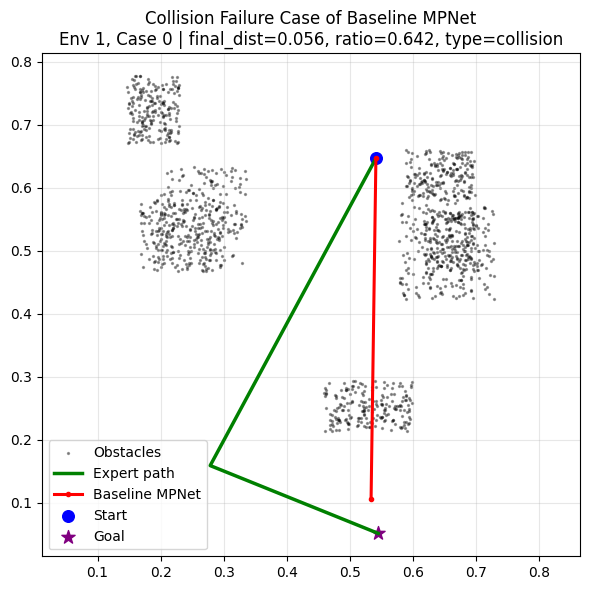

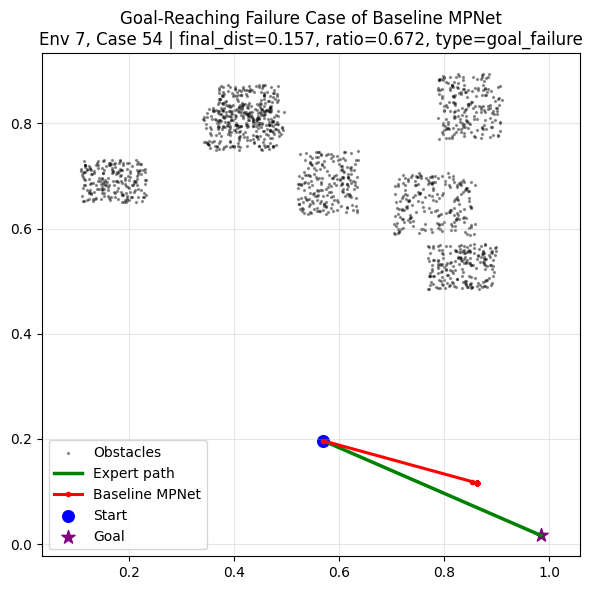

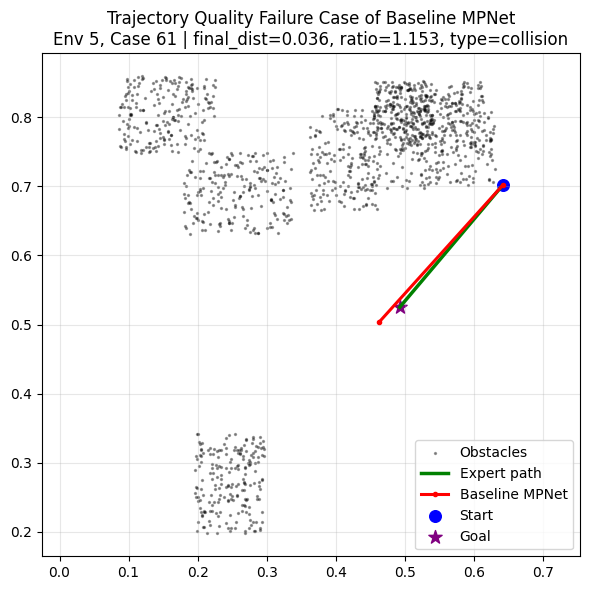

In [45]:
def plot_failure_case(case, title, save_path=None):
    plt.figure(figsize=(6, 6))

    obs_xy = case["obs_xy"]
    expert = case["expert"]
    path = case["path"]
    start = case["start"]
    goal = case["goal"]

    plt.scatter(
        obs_xy[:, 0],
        obs_xy[:, 1],
        s=2,
        c="black",
        alpha=0.35,
        label="Obstacles"
    )

    plt.plot(
        expert[:, 0],
        expert[:, 1],
        c="green",
        linewidth=2.5,
        label="Expert path"
    )

    plt.plot(
        path[:, 0],
        path[:, 1],
        c="red",
        linewidth=2.2,
        marker="o",
        markersize=3,
        label="Baseline MPNet"
    )

    plt.scatter(start[0], start[1], c="blue", s=70, label="Start")
    plt.scatter(goal[0], goal[1], c="purple", s=100, marker="*", label="Goal")

    info = (
        f"Env {case['env']}, Case {case['case']} | "
        f"final_dist={case['final_dist']:.3f}, "
        f"ratio={case['ratio']:.3f}, "
        f"type={','.join(case['failure_type'])}"
    )

    plt.title(title + "\n" + info)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_failure_case(
    collision_case,
    "Collision Failure Case of Baseline MPNet",
    "/content/collision_failure_case.png"
)

plot_failure_case(
    goal_case,
    "Goal-Reaching Failure Case of Baseline MPNet",
    "/content/goal_failure_case.png"
)

plot_failure_case(
    unstable_case,
    "Trajectory Quality Failure Case of Baseline MPNet",
    "/content/unstable_trajectory_case.png"
)


In [46]:
def collision_severity(case, threshold=0.03, samples_per_segment=50):
    obs_xy = case["obs_xy"]
    path = case["path"]
    count = 0

    for i in range(len(path) - 1):
        p0 = path[i]
        p1 = path[i + 1]

        for a in np.linspace(0, 1, samples_per_segment):
            p = (1 - a) * p0 + a * p1
            if is_in_collision(p, obs_xy, threshold):
                count += 1

    return count


collision_candidates = [
    c for c in failure_cases
    if c["collision"]
    and c["final_dist"] <= 0.1
    and c["expert_length"] > 0.4
]

goal_candidates = [
    c for c in failure_cases
    if (not c["collision"])
    and c["final_dist"] > 0.12
    and c["expert_length"] > 0.3
]

collision_case = max(collision_candidates, key=collision_severity)
goal_case = max(goal_candidates, key=lambda x: x["final_dist"])

print("collision:", collision_case["env"], collision_case["case"],
      collision_case["final_dist"], collision_case["ratio"],
      "severity:", collision_severity(collision_case))

print("goal:", goal_case["env"], goal_case["case"],
      goal_case["final_dist"], goal_case["ratio"])


collision: 6 94 0.09978345781564713 0.7579517379819376 severity: 122
goal: 7 54 0.15701156854629517 0.6723884293249958


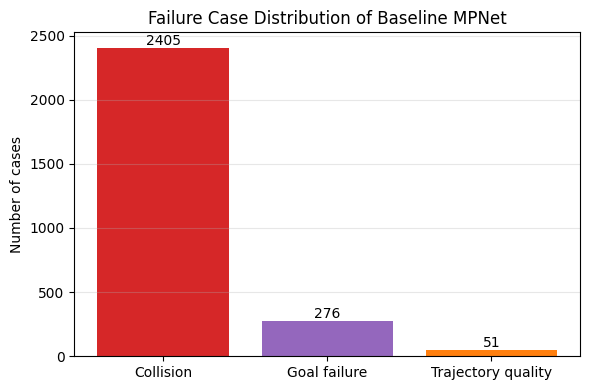

In [47]:
labels = ["Collision", "Goal failure", "Trajectory quality"]
values = [len(collision_cases), len(goal_failure_cases), len(unstable_cases)]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=["#d62728", "#9467bd", "#ff7f0e"])
plt.ylabel("Number of cases")
plt.title("Failure Case Distribution of Baseline MPNet")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v + 20, str(v), ha="center")

plt.tight_layout()
plt.savefig("/content/failure_case_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


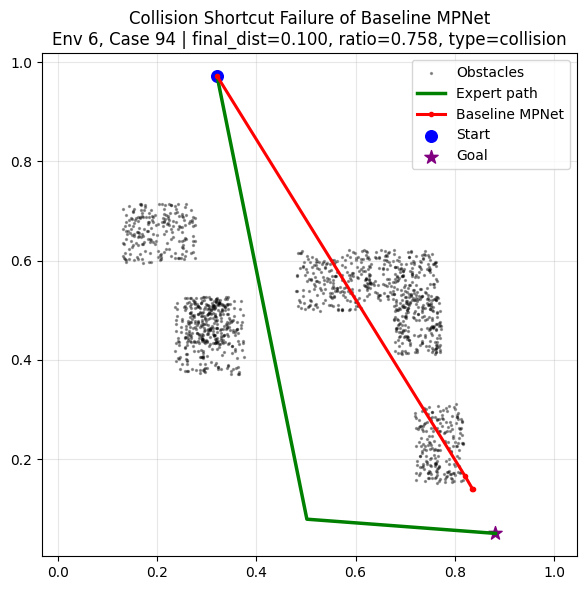

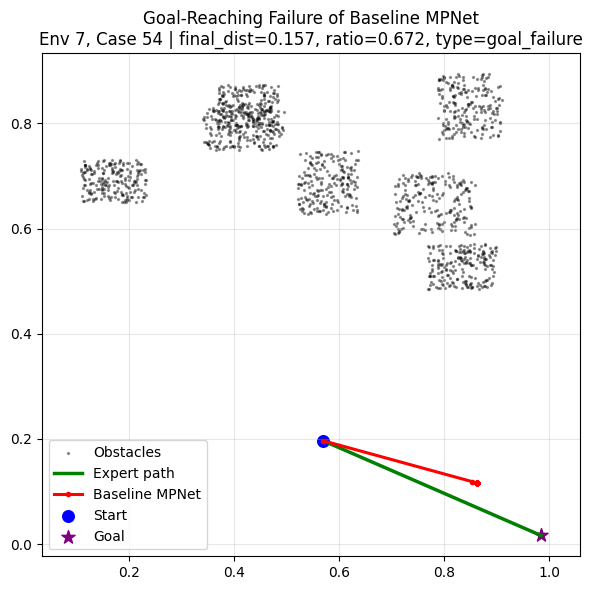

In [48]:
plot_failure_case(
    collision_case,
    "Collision Shortcut Failure of Baseline MPNet",
    "/content/collision_shortcut_failure.png"
)

plot_failure_case(
    goal_case,
    "Goal-Reaching Failure of Baseline MPNet",
    "/content/goal_reaching_failure.png"
)


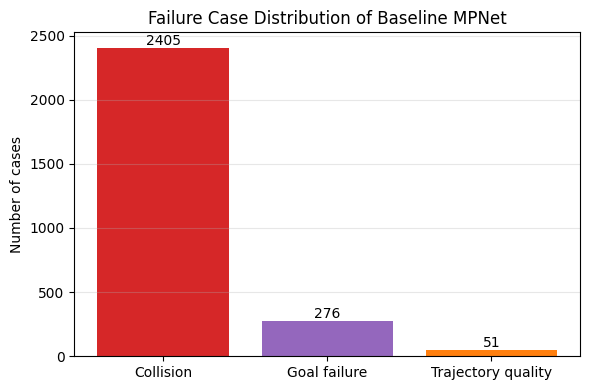

In [49]:
labels = ["Collision", "Goal failure", "Trajectory quality"]
values = [len(collision_cases), len(goal_failure_cases), len(unstable_cases)]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=["#d62728", "#9467bd", "#ff7f0e"])
plt.ylabel("Number of cases")
plt.title("Failure Case Distribution of Baseline MPNet")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(values):
    plt.text(i, v + 20, str(v), ha="center")

plt.tight_layout()
plt.savefig("/content/failure_case_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [50]:
from matplotlib.patches import Circle

def get_collision_points(path, obs_xy, threshold=0.03, samples_per_segment=80):
    collision_points = []

    for i in range(len(path) - 1):
        p0 = path[i]
        p1 = path[i + 1]

        for a in np.linspace(0, 1, samples_per_segment):
            p = (1 - a) * p0 + a * p1
            if is_in_collision(p, obs_xy, threshold):
                collision_points.append(p)

    return np.array(collision_points)


def plot_failure_case_enhanced(case, title, save_path=None, goal_radius=0.1):
    plt.figure(figsize=(6, 6))
    ax = plt.gca()

    obs_xy = case["obs_xy"]
    expert = case["expert"]
    path = case["path"]
    start = case["start"]
    goal = case["goal"]
    endpoint = path[-1]

    plt.scatter(obs_xy[:, 0], obs_xy[:, 1], s=3, c="black", alpha=0.45, label="Obstacles")

    goal_circle = Circle(
        (goal[0], goal[1]),
        goal_radius,
        fill=False,
        linestyle="--",
        linewidth=2,
        edgecolor="purple",
        alpha=0.8,
        label="Goal threshold"
    )
    ax.add_patch(goal_circle)

    plt.plot(expert[:, 0], expert[:, 1], c="green", linewidth=2.8, label="Expert path")
    plt.plot(path[:, 0], path[:, 1], c="red", linewidth=2.5, marker="o", markersize=3, label="Baseline MPNet")

    collision_pts = get_collision_points(path, obs_xy)
    if len(collision_pts) > 0:
        plt.scatter(
            collision_pts[:, 0],
            collision_pts[:, 1],
            s=28,
            c="orange",
            marker="x",
            linewidths=1.5,
            label="Detected collision"
        )

    plt.scatter(start[0], start[1], c="blue", s=80, label="Start")
    plt.scatter(goal[0], goal[1], c="purple", s=120, marker="*", label="Goal")
    plt.scatter(endpoint[0], endpoint[1], c="red", s=90, marker="s", label="MPNet endpoint")

    info = (
        f"Env {case['env']}, Case {case['case']} | "
        f"final_dist={case['final_dist']:.3f}, "
        f"ratio={case['ratio']:.3f}, "
        f"type={','.join(case['failure_type'])}"
    )

    plt.title(title + "\n" + info)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


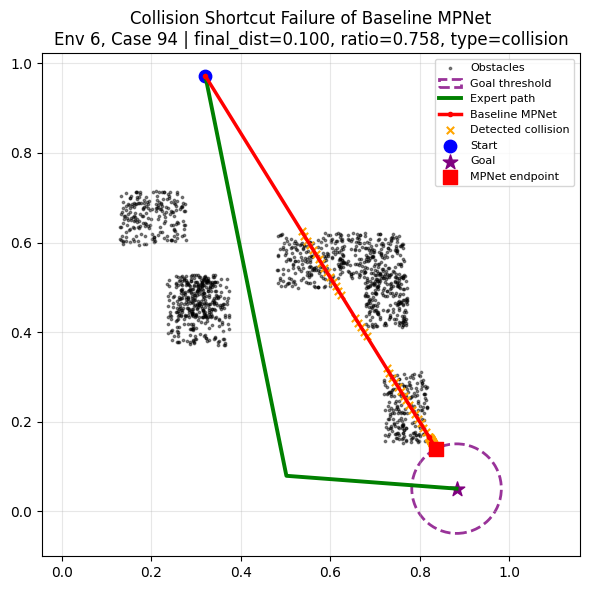

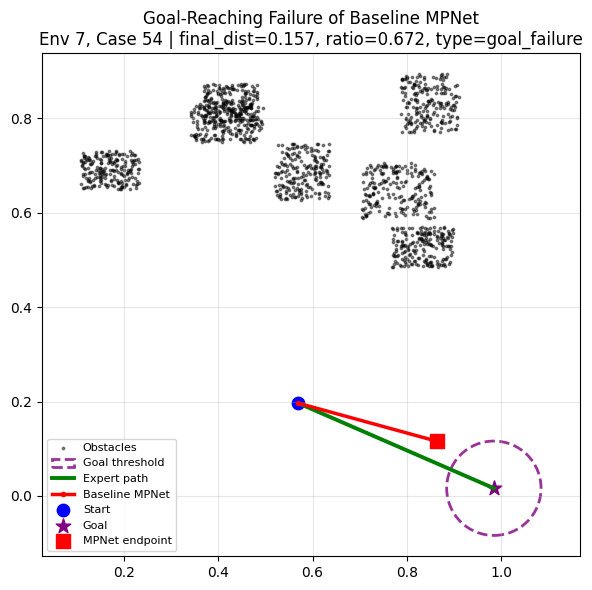

In [51]:
plot_failure_case_enhanced(
    collision_case,
    "Collision Shortcut Failure of Baseline MPNet",
    "/content/collision_shortcut_failure_enhanced.png"
)

plot_failure_case_enhanced(
    goal_case,
    "Goal-Reaching Failure of Baseline MPNet",
    "/content/goal_reaching_failure_enhanced.png"
)


In [52]:
!cp /content/collision_shortcut_failure_enhanced.png /content/drive/MyDrive/env6_case94_collision_shortcut_failure.png


In [53]:
!ls -lh /content/drive/MyDrive/env6_case94_collision_shortcut_failure.png


-rw------- 1 root root 361K May  6 14:03 /content/drive/MyDrive/env6_case94_collision_shortcut_failure.png


In [54]:
!cp /content/failure_case_distribution.png /content/drive/MyDrive/failure_case_distribution_baseline_mpnet.png
!ls -lh /content/drive/MyDrive/failure_case_distribution_baseline_mpnet.png


-rw------- 1 root root 75K May  6 14:07 /content/drive/MyDrive/failure_case_distribution_baseline_mpnet.png
